In [11]:
# Author: Teerapong Panboonyuen (Kao Panboonyuen)
# Project: GuidedBox - Guided Box-based Pseudo Mask Learning for Instance Segmentation
# Adapted for: IJmond Smoke Detection Dataset
# License: MIT License

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import yaml
import json
import os
from tqdm import tqdm

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

%matplotlib inline

Using device: cpu


In [12]:
# Load configuration
config_path = 'guidedbox_config.yaml'
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)

print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")

Config loaded:
  device: cpu
  num_classes: 1
  num_epochs: 10
  batch_size: 8
  learning_rate: 0.0001
  ema_alpha: 0.9
  img_size: 256
  img_npy_path: dataset/ijmond_bbox/img_npy
  bbox_labels_path: dataset/ijmond_bbox/bbox_labels_1_aug_2025.json
  save_path: guided_box_ijmond
  model_checkpoint: guided_box_ijmond/checkpoint


In [13]:
# Load and filter IJmond bbox labels
with open(config['bbox_labels_path'], 'r') as f:
    bbox_data = json.load(f)

all_records = bbox_data['data']
print(f"Total records in JSON: {len(all_records)}")

# Get available npy image IDs
npy_ids = set(f.replace('.npy', '') for f in os.listdir(config['img_npy_path']) if f.endswith('.npy'))
print(f"Total npy images: {len(npy_ids)}")

# Filter: only records that have a matching npy file
matched_records = [r for r in all_records if str(r['id']) in npy_ids]
print(f"Records with matching npy files: {len(matched_records)}")

# Label states indicating SMOKE with a bounding box:
#   0,1,3,4,6,8,9,10,13,15 -> smoke present (box confirmed or edited)
# Label states indicating NO SMOKE:
#   5,12,14 -> both reviewers removed box (no smoke)
# We keep smoke records (positive) for training with bbox supervision
SMOKE_STATES = {0, 1, 3, 4, 6, 8, 9, 10, 11, 13, 15}
NO_SMOKE_STATES = {5, 12, 14}

smoke_records = [r for r in matched_records if r['label_state'] in SMOKE_STATES]
no_smoke_records = [r for r in matched_records if r['label_state'] in NO_SMOKE_STATES]

print(f"\nSmoke records (with bbox): {len(smoke_records)}")
print(f"No-smoke records: {len(no_smoke_records)}")
print(f"Unlabeled/other: {len(matched_records) - len(smoke_records) - len(no_smoke_records)}")

# Use smoke records for training (they have valid bounding boxes)
train_records = smoke_records
print(f"\nUsing {len(train_records)} records for training")

Total records in JSON: 1536
Total npy images: 610
Records with matching npy files: 610

Smoke records (with bbox): 177
No-smoke records: 433
Unlabeled/other: 0

Using 177 records for training


Image shape: torch.Size([3, 256, 256]), Box: tensor([0.5217, 0.3967, 0.3367, 0.5083]), Mask shape: torch.Size([1, 256, 256])
Mask sum (pixels in box): 11180 / 65536


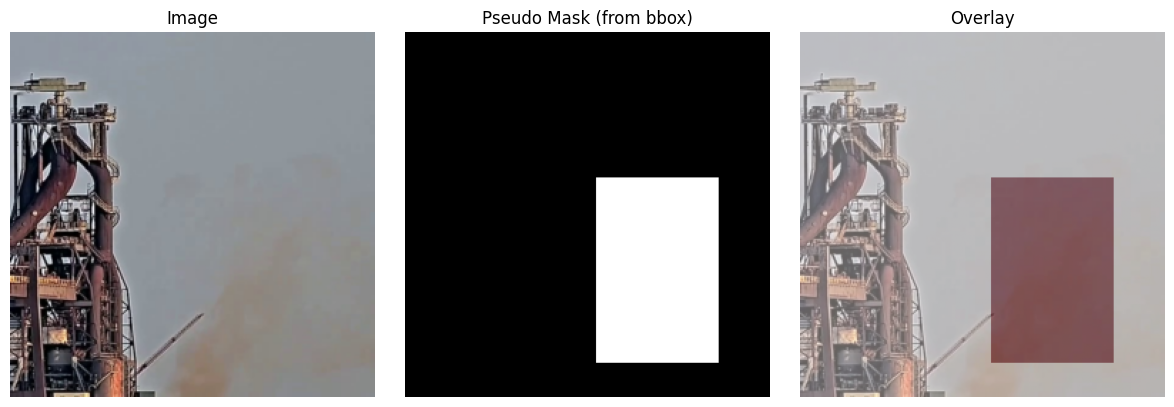

In [14]:
# Custom Dataset for IJmond Bbox Data
class IJmondBboxDataset(Dataset):
    """
    Loads .npy images and creates pseudo masks from bounding box annotations.
    
    For GuidedBox, we need:
    - images: RGB input images
    - boxes: bounding box coordinates [x, y, w, h] normalized to [0, 1]
    - masks: pseudo binary masks generated from bounding boxes
    """
    def __init__(self, records, img_npy_dir, img_size=256):
        self.records = records
        self.img_npy_dir = img_npy_dir
        self.img_size = img_size
        
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        record = self.records[idx]
        
        # Load image from .npy file
        img_path = os.path.join(self.img_npy_dir, f"{record['id']}.npy")
        image = np.load(img_path)  # (H, W, 3) uint8
        
        # Get original image dimensions and bbox
        h_img, w_img = record['h_image'], record['w_image']
        x_bbox, y_bbox = record['x_bbox'], record['y_bbox']
        w_bbox, h_bbox = record['w_bbox'], record['h_bbox']
        
        # The npy image might be a different size than h_image/w_image
        # (npy is 600x600 or 900x900, bbox coords are relative to h_image/w_image)
        actual_h, actual_w = image.shape[:2]
        scale_x = actual_w / w_img
        scale_y = actual_h / h_img
        
        # Scale bbox to actual image coordinates
        x_bbox_scaled = int(x_bbox * scale_x)
        y_bbox_scaled = int(y_bbox * scale_y)
        w_bbox_scaled = int(w_bbox * scale_x)
        h_bbox_scaled = int(h_bbox * scale_y)
        
        # Create pseudo mask from bounding box (binary: 1 inside box, 0 outside)
        pseudo_mask = np.zeros((actual_h, actual_w), dtype=np.float32)
        x1 = max(0, x_bbox_scaled)
        y1 = max(0, y_bbox_scaled)
        x2 = min(actual_w, x_bbox_scaled + w_bbox_scaled)
        y2 = min(actual_h, y_bbox_scaled + h_bbox_scaled)
        pseudo_mask[y1:y2, x1:x2] = 1.0
        
        # Resize image and mask
        image_pil = Image.fromarray(image).resize((self.img_size, self.img_size), Image.BILINEAR)
        mask_pil = Image.fromarray((pseudo_mask * 255).astype(np.uint8)).resize(
            (self.img_size, self.img_size), Image.NEAREST
        )
        
        # Convert to tensors
        image_tensor = TF.to_tensor(image_pil)  # [3, H, W], [0, 1]
        mask_tensor = torch.from_numpy(np.array(mask_pil)).float() / 255.0
        mask_tensor = mask_tensor.unsqueeze(0)  # [1, H, W]
        
        # Normalize image (ImageNet stats for ResNet50 backbone)
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        
        # Normalized bbox [x, y, w, h] in [0, 1] range (relative to resized image)
        box_tensor = torch.tensor([
            x_bbox / w_img,
            y_bbox / h_img,
            w_bbox / w_img,
            h_bbox / h_img
        ], dtype=torch.float32)
        
        return image_tensor, box_tensor, mask_tensor

# Test the dataset
test_ds = IJmondBboxDataset(train_records[:5], config['img_npy_path'], img_size=config['img_size'])
sample_img, sample_box, sample_mask = test_ds[0]
print(f"Image shape: {sample_img.shape}, Box: {sample_box}, Mask shape: {sample_mask.shape}")
print(f"Mask sum (pixels in box): {sample_mask.sum().item():.0f} / {sample_mask.numel()}")

# Visualize a sample
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# Denormalize image
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = (sample_img * std + mean).permute(1, 2, 0).numpy().clip(0, 1)

axes[0].imshow(img_display)
axes[0].set_title("Image")
axes[0].axis('off')

axes[1].imshow(sample_mask[0], cmap='gray')
axes[1].set_title("Pseudo Mask (from bbox)")
axes[1].axis('off')

axes[2].imshow(img_display)
axes[2].imshow(sample_mask[0], alpha=0.4, cmap='Reds')
axes[2].set_title("Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [15]:
# Create Data Loaders
IMG_SIZE = config['img_size']
BATCH_SIZE = config['batch_size']
VAL_SPLIT = 0.2

# Create full dataset
full_dataset = IJmondBboxDataset(train_records, config['img_npy_path'], img_size=IMG_SIZE)

# Split into train and validation
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batches per epoch: {len(train_loader)}")

# Verify a batch
images, boxes, masks = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Images: {images.shape}")
print(f"  Boxes: {boxes.shape}")
print(f"  Masks: {masks.shape}")

Training samples: 142
Validation samples: 35
Batches per epoch: 18

Batch shapes:
  Images: torch.Size([8, 3, 256, 256])
  Boxes: torch.Size([8, 4])
  Masks: torch.Size([8, 1, 256, 256])

Batch shapes:
  Images: torch.Size([8, 3, 256, 256])
  Boxes: torch.Size([8, 4])
  Masks: torch.Size([8, 1, 256, 256])


In [16]:
# GuidedBox Model - Original Architecture by Teerapong Panboonyuen
# Adapted for binary smoke segmentation from bounding box supervision
#
# NOTE: The original code uses `self.backbone = models.resnet50(pretrained=True)`
# but ResNet50's default forward() returns [B, 1000] (classification output).
# The teacher/student Conv2d layers need 4D feature maps [B, 2048, H, W].
# So we extract only the convolutional layers (removing avgpool + fc).

class GuidedBoxModel(nn.Module):
    def __init__(self, config):
        super(GuidedBoxModel, self).__init__()
        
        # Load ResNet50 and extract only convolutional feature layers
        resnet = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,  # [B, 256, H/4, W/4]
            resnet.layer2,  # [B, 512, H/8, W/8]
            resnet.layer3,  # [B, 1024, H/16, W/16]
            resnet.layer4,  # [B, 2048, H/32, W/32]
        )
        
        self.teacher = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.student = nn.Sequential(
            nn.Conv2d(2048, 1024, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(1024, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, config['num_classes'], kernel_size=1)
        )
        self.alpha = config['ema_alpha']

    def forward(self, images, boxes=None, masks=None):
        features = self.backbone(images)       # [B, 2048, H/32, W/32]
        teacher_output = self.teacher(features)  # [B, num_classes, H/32, W/32]
        student_output = self.student(features)  # [B, num_classes, H/32, W/32]
        
        # Upsample predictions to original image size
        teacher_output = F.interpolate(teacher_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        student_output = F.interpolate(student_output, size=images.shape[2:], mode='bilinear', align_corners=False)
        
        if self.training:
            loss = self.compute_loss(teacher_output, student_output, boxes, masks)
            return loss
        else:
            return student_output

    def compute_loss(self, teacher_output, student_output, boxes, masks):
        """
        Compute combined loss for training.
        - box_loss: MSE between teacher and student (consistency regularization)
        - mask_loss: robust pseudo mask loss with confidence weighting
        """
        conf_scores = self.compute_confidence_scores(teacher_output, student_output)
        mask_loss = self.robust_pseudo_mask_loss(student_output, masks, conf_scores)
        box_loss = F.mse_loss(teacher_output, student_output)
        return box_loss + mask_loss

    def robust_pseudo_mask_loss(self, preds, pseudo_masks, conf_scores):
        """Compute robust pseudo mask loss with confidence weighting."""
        pixel_loss = F.binary_cross_entropy_with_logits(preds, pseudo_masks)
        affinity_loss = self.enhanced_mask_affinity_loss(preds, pseudo_masks)
        return torch.mean(conf_scores * (0.4 * pixel_loss + 0.1 * affinity_loss))

    def enhanced_mask_affinity_loss(self, preds, pseudo_masks):
        """Compute enhanced mask affinity loss using local context."""
        eps = 1e-7
        affinity_loss = 0.0
        for i in range(preds.size(0)):
            mask_pred = torch.sigmoid(preds[i])
            mask_pred = torch.clamp(mask_pred, eps, 1 - eps)
            
            neighbors = F.max_pool2d(
                mask_pred.unsqueeze(0), kernel_size=3, stride=1, padding=1
            ).squeeze(0) > 0.45
            
            fg_loss = 0.0
            bg_loss = 0.0
            if neighbors.sum() > 0:
                fg_loss = -torch.mean(torch.log(mask_pred[neighbors]))
            if (~neighbors).sum() > 0:
                bg_loss = -torch.mean(torch.log(1 - mask_pred[~neighbors]))
            
            affinity_loss += fg_loss + bg_loss
        return affinity_loss / preds.size(0)

    def compute_confidence_scores(self, teacher_output, student_output):
        """Compute confidence scores via cosine similarity."""
        return torch.sigmoid(F.cosine_similarity(teacher_output, student_output))
    
    def update_teacher(self):
        """Update teacher network parameters using EMA."""
        for t_param, s_param in zip(self.teacher.parameters(), self.student.parameters()):
            t_param.data = self.alpha * t_param.data + (1 - self.alpha) * s_param.data

# Count parameters
model = GuidedBoxModel(config)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 70,698,050
Trainable parameters: 70,698,050


In [17]:
# Initialize model and move to device
model = GuidedBoxModel(config)
model = model.to(config['device'])

# Freeze backbone for first few epochs (optional, speeds up training)
# for param in model.backbone.parameters():
#     param.requires_grad = False

print(f"Model on device: {config['device']}")
print(f"Backbone frozen: False")

Model on device: cpu
Backbone frozen: False


In [18]:
# Helper functions for metrics
def calculate_iou(pred, target, threshold=0.5):
    """Calculate Intersection over Union"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    union = pred_binary.sum() + target.sum() - intersection
    return (intersection / (union + 1e-8)).item()

def calculate_dice(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred_binary = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred_binary * target).sum()
    return (2 * intersection / (pred_binary.sum() + target.sum() + 1e-8)).item()

# Lists for tracking metrics
train_losses = []
val_losses = []
val_ious = []

print("Metrics functions ready.")

Metrics functions ready.


In [ ]:
# Training Loop
NUM_EPOCHS = config['num_epochs']
LEARNING_RATE = config['learning_rate']
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Training for {NUM_EPOCHS} epochs, lr={LEARNING_RATE}")
print(f"Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
print("-" * 60)

for epoch in range(NUM_EPOCHS):
    # --- Training phase ---
    model.train()
    epoch_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    
    for images, boxes, masks in pbar:
        images = images.to(config['device'])
        boxes = boxes.to(config['device'])
        masks = masks.to(config['device'])
        
        # Forward pass - model returns loss during training
        loss = model(images, boxes=boxes, masks=masks)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Update teacher network with EMA
        model.update_teacher()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- Validation phase ---
    model.eval()
    epoch_val_loss = 0.0
    epoch_iou = 0.0
    
    with torch.no_grad():
        for images, boxes, masks in val_loader:
            images = images.to(config['device'])
            boxes = boxes.to(config['device'])
            masks = masks.to(config['device'])
            
            # Get predictions (model returns student output in eval mode)
            outputs = model(images)
            
            # Compute validation loss manually
            val_loss = F.binary_cross_entropy_with_logits(outputs, masks)
            epoch_val_loss += val_loss.item()
            epoch_iou += calculate_iou(outputs, masks)
    
    avg_val_loss = epoch_val_loss / len(val_loader)
    avg_iou = epoch_iou / len(val_loader)
    val_losses.append(avg_val_loss)
    val_ious.append(avg_iou)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, IoU={avg_iou:.4f}")

print("\n" + "=" * 60)
print("Training complete!")

# Save the trained model
os.makedirs(config['save_path'], exist_ok=True)
save_file = os.path.join(config['save_path'], 'guidedbox_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_losses': train_losses,
    'val_losses': val_losses,
    'val_ious': val_ious,
    'epoch': NUM_EPOCHS,
    'config': config,
}, save_file)
print(f"Model saved to: {save_file}")

Training for 10 epochs, lr=0.0001
Dataset: 142 train, 35 val samples
------------------------------------------------------------


Epoch 1/10: 100%|██████████| 18/18 [03:42<00:00, 12.38s/it, loss=0.2844]



Epoch 1/10: Train Loss=0.6180, Val Loss=0.5890, IoU=0.0000


Epoch 2/10: 100%|██████████| 18/18 [04:28<00:00, 14.89s/it, loss=0.1046]



Epoch 2/10: Train Loss=0.1942, Val Loss=0.2625, IoU=0.0000


...

Epoch 4/10: 100%|██████████| 18/18 [05:25<00:00, 18.08s/it, loss=0.0464]



Epoch 4/10: Train Loss=0.0553, Val Loss=0.1225, IoU=0.0000


Epoch 5/10: 100%|██████████| 18/18 [06:00<00:00, 20.01s/it, loss=0.0539]



Epoch 5/10: Train Loss=0.0479, Val Loss=0.1186, IoU=0.0000


Epoch 6/10:   6%|▌         | 1/18 [00:19<05:34, 19.67s/it, loss=0.0672]

In [ ]:
# Plot Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# IoU plot
axes[1].plot(val_ious, label='Validation IoU', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Validation IoU Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

if val_ious:
    print(f"Best Validation IoU: {max(val_ious):.4f} at epoch {val_ious.index(max(val_ious)) + 1}")

In [ ]:
# Visualize Predictions on Validation Set
def visualize_predictions(model, dataloader, num_samples=4):
    """Display sample predictions vs pseudo mask ground truth"""
    model.eval()
    
    # Get a batch
    images, boxes, masks = next(iter(dataloader))
    images = images.to(config['device'])
    
    with torch.no_grad():
        predictions = model(images)
        predictions = torch.sigmoid(predictions)  # Convert logits to probabilities
    
    # Move to CPU for plotting
    images = images.cpu()
    masks = masks.cpu()
    boxes = boxes.cpu()
    predictions = predictions.cpu()
    
    # Denormalize images
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    num_samples = min(num_samples, len(images))
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_samples):
        img = images[i] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        gt_mask = masks[i, 0].numpy()
        pred_mask = predictions[i, 0].numpy()
        pred_binary = (pred_mask > 0.5).astype(float)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(gt_mask, cmap='gray')
        axes[i, 1].set_title("Pseudo Mask (bbox)")
        axes[i, 1].axis('off')
        
        axes[i, 2].imshow(pred_mask, cmap='hot')
        axes[i, 2].set_title("Prediction (Prob)")
        axes[i, 2].axis('off')
        
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(pred_binary, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title("Overlay")
        axes[i, 3].axis('off')
    
    plt.suptitle("GuidedBox Predictions on IJmond Validation Set", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_loader, num_samples=4)

In [ ]:
# Final Evaluation on Validation Set
model.eval()
total_iou = 0
total_dice = 0
num_batches = 0

with torch.no_grad():
    for images, boxes, masks in val_loader:
        images = images.to(config['device'])
        masks = masks.to(config['device'])
        
        outputs = model(images)
        
        total_iou += calculate_iou(outputs, masks)
        total_dice += calculate_dice(outputs, masks)
        num_batches += 1

final_iou = total_iou / num_batches
final_dice = total_dice / num_batches

print("=" * 50)
print("Final Evaluation on Validation Set")
print("=" * 50)
print(f"IoU (Intersection over Union): {final_iou:.4f}")
print(f"Dice Coefficient: {final_dice:.4f}")
print("=" * 50)